In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/creditcard.csv")
print(df.shape)
df.info()
df.head()

(284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 2

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


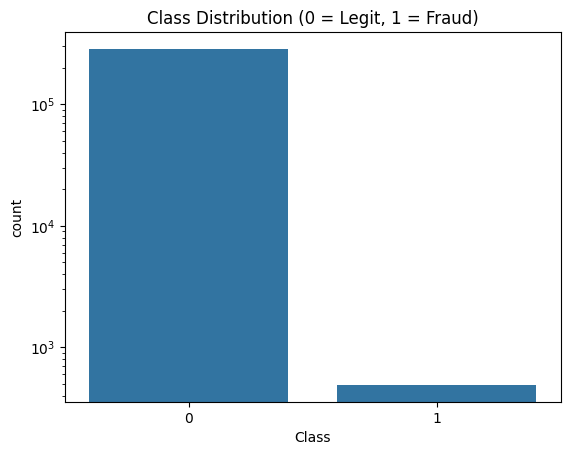

In [2]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100
print(class_counts)
print(class_pct)

sns.countplot(x="Class", data=df)
plt.title("Class Distribution (0 = Legit, 1 = Fraud)")
plt.yscale("log")  # log scale, otherwise fraud bar is invisible
plt.show()

In [3]:
df.isnull().sum().sum()  # should be 0 for this dataset

np.int64(0)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(x=df[df.Class == 0]["Amount"], bins=50, ax=ax[0])
ax[0].set_title("Legitimate Transaction Amounts")
sns.histplot(x=df[df.Class == 1]["Amount"], bins=50, ax=ax[1])
ax[1].set_title("Fraudulent Transaction Amounts")
plt.show()

df.groupby("Class")["Amount"].describe()

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


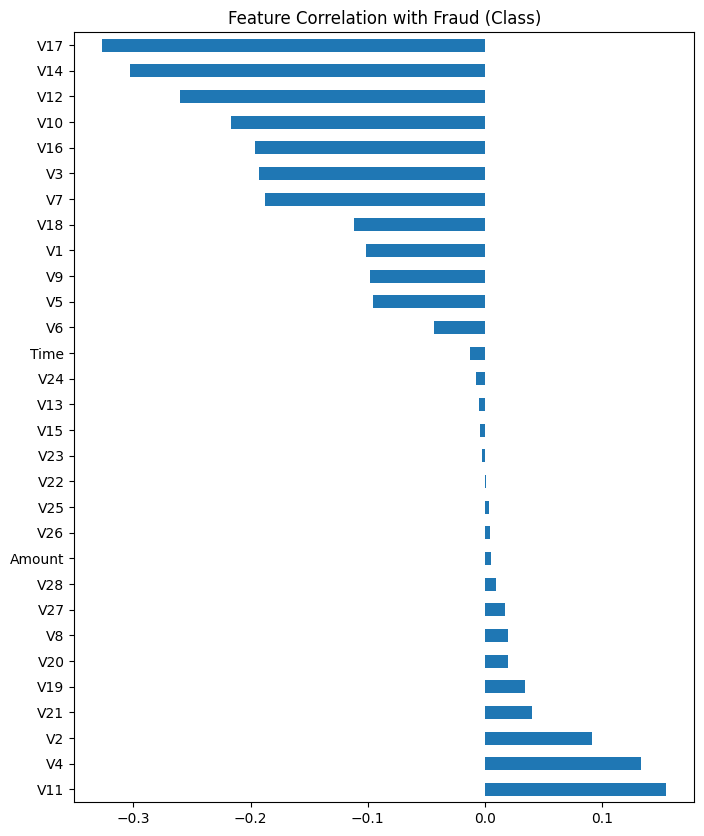

In [5]:
corr = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(8, 10))
corr.drop("Class").plot(kind="barh")
plt.title("Feature Correlation with Fraud (Class)")
plt.show()

In [7]:
# Key findings
# - Dataset: 284,807 transactions, 30 features (Time, V1–V28 PCA components, Amount) + target (Class)
# - Severe class imbalance: 0.173% fraud (492 cases) vs 99.827% legitimate
# - No missing values
# - Fraudulent transactions show a different amount distribution than legitimate ones
# - V17, V14, V12, V10 (etc.) show the strongest correlation with fraud
# - Given the imbalance, evaluation must prioritize precision/recall/PR-AUC over accuracy

SyntaxError: invalid character '–' (U+2013) (319095818.py, line 2)